# Notebook for Lorenz Experiment

## Data Generation + PCA/DCA reconstruction

In [1]:
import numpy as np

import sys
from pathlib import Path

# Ensure the synthetic package is on the path
synthetic_path = Path("../synthetic").resolve()
if str(synthetic_path) not in sys.path:
    sys.path.insert(0, str(synthetic_path))

from synthetic_generator import generate_syn, load_and_plot_data

/Users/ruimeng/workspace/CPIC_dev/synthetic/synthetic_generator.py:209: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  X_noisy_dset = f.create_dataset("X_noisy", (len(snr_vals), num_samples, N))
/Users/ruimeng/workspace/CPIC_dev/synthetic/synthetic_generator.py:210: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  X_pca_trans_dset = f.create_dataset("X_pca_trans", (len(snr_vals), num_samples, 3))
/Users/ruimeng/workspace/CPIC_dev/synthetic/synthetic_generator.py:211: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  X_dca_trans_dset = f.create_dataset("X_dca_trans", (len(snr_vals), num_samples, 3))


snr = 1


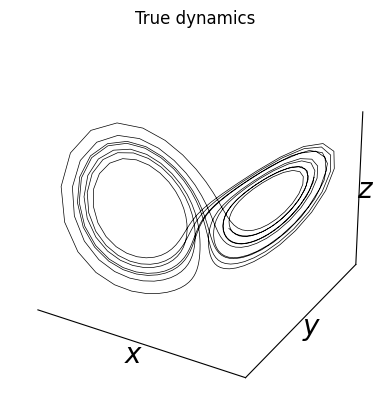

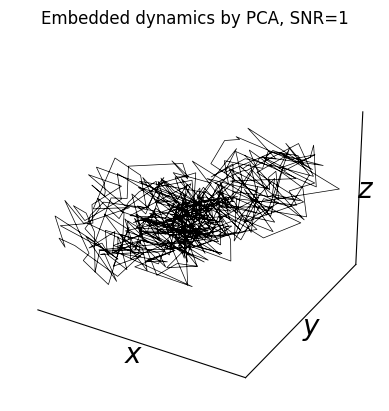

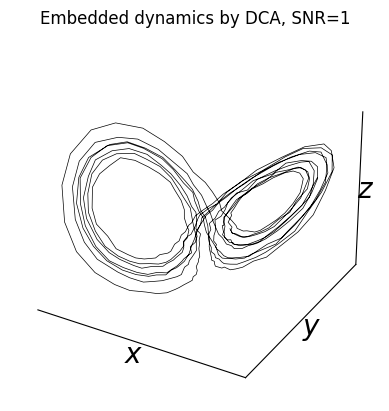

No plot for R2 scores


In [2]:
seed = 22

np.random.seed(seed)
RESULTS_FILENAME = "../synthetic/data/lorenz/lorenz_demo.hdf5"
do_vis = True

# Set parameters
T = 4
N = 30
noise_dim = 5
if RESULTS_FILENAME.endswith("lorenz_results.hdf5"):
    snr_vals = np.array([0.01, 0.02, 0.05, 0.1, 1])
elif RESULTS_FILENAME.endswith("lorenz_exploration.hdf5"):
    snr_vals = np.logspace(-3.0, -1.0, num=10)
elif RESULTS_FILENAME.endswith("lorenz_demo.hdf5"):
    snr_vals = np.array([1])
else:
    raise ValueError(f"Unknown RESULTS_FILENAME: {RESULTS_FILENAME}")

# generate data
generate_syn(T, N, noise_dim, snr_vals, random_seed=seed, RESULTS_FILENAME=RESULTS_FILENAME)

# load data and plot
load_and_plot_data(RESULTS_FILENAME, do_vis=do_vis)